# World Cup Predictor: Episode 3b — Dixon-Coles Model
By Karl Estampador

## What this notebook does

Episode 4 extends the Poisson GLM with two improvements:

1. **Exponential time decay** — recent matches receive higher weight:
   `w_i = exp(−ξ · Δt_i / 365)`

2. **Dixon-Coles τ correction** — adjusts the four low-scoring outcomes that
   Poisson systematically mispredicts: (0,0), (1,0), (0,1), (1,1).

Same no-intercept parameterisation as Episode 3:
```
log(λ_home) = α[home] + β[away] + γ · I(not neutral)
log(λ_away) = α[away] + β[home]
P_corrected(x,y) = τ(x,y,λ_h,λ_a,ρ) × Poisson(x,λ_h) × Poisson(y,λ_a)
```

## How to use in `predictions.ipynb`

```python
# Episode 4:
%run ../models/dc_model.ipynb
```

Set `RUN_COMPARISON = False` (Section 9) before running from `predictions.ipynb`
to skip the expensive Poisson re-fit.

## Function reference

| Function | Returns |
|---|---|
| `predict_group_match(home, away, neutral=True)` | `(home_goals, away_goals, winner_or_None)` |
| `predict_knockout_winner(home, away, neutral=True)` | `(winner, loser, win_prob, lose_prob)` |
| `predict_expected_goals(home, away, neutral=True)` | `(λ_home, λ_away)` — raw rates, no τ |
| `predict_win_probabilities(home, away, neutral=True, group_stage=False)` | `(p_hw, p_draw, p_aw)` |
| `get_elo(team_name)` | `float` (standings / tiebreakers only) |
| `compare_teams(team_a, team_b, neutral=True)` | Side-by-side α/β + expected goals |
| `wc_team_ratings` | `DataFrame` — all 48 WC teams with attack/defense ranks |

In [1]:
import warnings
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.optimize import minimize
from scipy.stats import poisson as poisson_dist
from scipy.special import gammaln

# Ensure scripts/ (the data pipeline) is importable regardless of CWD
sys.path.insert(0, str(Path('..').resolve()))
from scripts.data_pipeline import load_from_db

warnings.filterwarnings('ignore')
pd.set_option('future.infer_string', False)  # pandas 3.0 compat: keep object-dtype strings
np.random.seed(42)

DATA            = Path('../data/historical')
TOURNAMENT_DATA = Path('../data/tournament')
COMBINED_DATA   = Path('../data/combined')
OUTPUTS = Path('../outputs')
OUTPUTS.mkdir(exist_ok=True)

print('Imports OK')

Imports OK


---
## Section 1 — Data Preparation

| File | What it contains |
|---|---|
| `data/combined/master_matches.db` (via `load_from_db`) | Every international match since 1872 (historical CSV + API) |
| `data/historical/shootouts.csv` | Penalty-shootout winners (folded into the master dataset) |
| `data/teams.csv` | 2026 WC teams and groups |

In [2]:
# --- Load data (master dataset = historical CSV + football-data.org API) ---
results_all = load_from_db()
results_all['date'] = pd.to_datetime(results_all['date'])

# Reconstruct the shootouts view the downstream code expects
_sh = results_all[results_all['is_shootout']].copy()
shootouts_all = _sh[['date', 'home_team', 'away_team']].copy()
shootouts_all['winner'] = _sh['shootout_winner']

teams_df      = pd.read_csv(TOURNAMENT_DATA / 'teams.csv')

# Guard against schema changes
assert {'date','home_team','away_team','home_score','away_score','tournament','neutral'} \
    <= set(results_all.columns),   'results.csv schema mismatch'
assert {'date','home_team','away_team','winner'} \
    <= set(shootouts_all.columns), 'shootouts.csv schema mismatch'

print(f'results.csv   : {len(results_all):,} rows')
print(f'shootouts.csv : {len(shootouts_all):,} rows')

# --- Tournament filter ---
print('\nAll unique tournament values (first 20 shown):')
all_trn = sorted(results_all['tournament'].unique())
print(all_trn[:20], '...' if len(all_trn) > 20 else '')

friendly_mask  = results_all['tournament'].str.contains('Friendly', case=False, na=False)
df_competitive = results_all[~friendly_mask].copy().reset_index(drop=True)

# Drop rows with missing scores (70 rows in dataset; can't compute log-likelihood on them)
n_before = len(df_competitive)
df_competitive = df_competitive.dropna(subset=['home_score', 'away_score']).copy().reset_index(drop=True)
print(f'Dropped {n_before - len(df_competitive)} rows with missing scores')

print(f'\nAfter removing Friendlies + missing scores: {len(df_competitive):,} rows')
print('Remaining tournament types (first 30):')
print(sorted(df_competitive['tournament'].unique())[:30])

# --- Parse neutral as boolean ---
df_competitive['neutral'] = df_competitive['neutral'].astype(str).str.upper() == 'TRUE'

# --- Decade summary ---
df_competitive['year'] = df_competitive['date'].dt.year
print('\nMatches per decade:')
for decade, cnt in df_competitive.groupby((df_competitive['year'] // 10) * 10).size().items():
    print(f'  {decade}s : {cnt:,}')

# --- Host-nation name check ---
print('\n--- Host-nation name check ---')
print('teams.csv host entries:')
for tn in ['USA', 'Mexico', 'Canada']:
    found = (teams_df['team_name'] == tn).any()
    print(f'  "{tn}" in teams.csv : {found}')

all_results_names = set(results_all['home_team'].tolist() + results_all['away_team'].tolist())
print('results.csv host entries (canonical form):')
for rn in ['United States', 'Mexico', 'Canada']:
    found = rn in all_results_names
    print(f'  "{rn}" in results.csv : {found}')
print('Mapping: teams.csv "USA" → results.csv "United States" (via ELO_ALIASES)')

# --- Team match counts (keyed by raw results.csv names) ---
home_c = df_competitive['home_team'].value_counts()
away_c = df_competitive['away_team'].value_counts()
team_match_counts = home_c.add(away_c, fill_value=0).to_dict()
print(f'\nteam_match_counts : {len(team_match_counts)} teams')
print(f'United States appearances : {int(team_match_counts.get("United States", 0))}')

results.csv   : 49,481 rows
shootouts.csv : 677 rows

All unique tournament values (first 20 shown):
['ABCS Tournament', 'AFC Asian Cup', 'AFC Asian Cup qualification', 'AFC Challenge Cup', 'AFC Challenge Cup qualification', 'AFC Solidarity Cup', 'AFF Championship', 'AFF Championship qualification', 'ASEAN Championship', 'ASEAN Championship qualification', 'African Cup of Nations', 'African Cup of Nations qualification', 'African Friendship Games', 'Afro-Asian Games', 'Al Ain International Cup', 'All-African Games', 'Amílcar Cabral Cup', 'Arab Cup', 'Arab Cup qualification', 'Asian Games'] ...
Dropped 70 rows with missing scores

After removing Friendlies + missing scores: 31,025 rows
Remaining tournament types (first 30):
['ABCS Tournament', 'AFC Asian Cup', 'AFC Asian Cup qualification', 'AFC Challenge Cup', 'AFC Challenge Cup qualification', 'AFC Solidarity Cup', 'AFF Championship', 'AFF Championship qualification', 'ASEAN Championship', 'ASEAN Championship qualification', 'African 

---
## Section 2 — ELO Helpers & Team-Name Canonicalization

**Critical:** `teams.csv` and `results.csv` use different spellings for several 2026
participants. `TEAM_ALIASES` reuses `ELO_ALIASES` — no second copy maintained.
`_HOST_NATIONS` uses canonical (results.csv) names.

In [3]:
# --- ELO helpers (verbatim from model.ipynb / lr_model.ipynb) ---

elo_raw  = pd.read_csv(TOURNAMENT_DATA / 'elo_ratings_wc2026.csv')
elo_2026 = (
    elo_raw[elo_raw['snapshot_date'] == '2026-05-27']
    .copy()
    .reset_index(drop=True)
)
assert len(elo_2026) > 0, 'No rows for snapshot 2026-05-27'

ELO_ALIASES: dict[str, str] = {
    'USA':              'United States',
    'IR Iran':          'Iran',
    "Côte d'Ivoire":    'Ivory Coast',
    'Cabo Verde':       'Cape Verde',
    'DR Congo':         'DR Congo',
    'United States':    'United States',
    'Iran':             'Iran',
    'Ivory Coast':      'Ivory Coast',
    'Cape Verde':       'Cape Verde',
    'Czech Republic':   'Czechia',
    'Czechia':           'Czech Republic',   # reverse: teams.csv 'Czechia' → results.csv 'Czech Republic'
    'Cura\u00e7ao':     'Cura\u00e7ao',
}

_elo_lookup: dict[str, float] = dict(zip(elo_2026['country'], elo_2026['rating']))

def _canonical_elo(name: str) -> str:
    return ELO_ALIASES.get(name, name)

def get_elo(team_name: str) -> float:
    """Pre-tournament ELO rating. Used by predictions.ipynb for standings/tiebreakers only."""
    canon = _canonical_elo(team_name)
    if canon in _elo_lookup:
        return _elo_lookup[canon]
    if team_name in _elo_lookup:
        return _elo_lookup[team_name]
    raise KeyError(f'No Elo rating found for "{team_name}" (canonical: "{canon}")')

print(f'ELO lookup ready ({len(_elo_lookup)} teams)')

# --- Team-name canonicalization ---
TEAM_ALIASES = ELO_ALIASES   # same dict — no second copy

def _canonical_team(name: str) -> str:
    """Translate teams.csv-style names (e.g. 'USA') to results.csv-style names ('United States')."""
    return TEAM_ALIASES.get(name, name)

_HOST_NATIONS = {'United States', 'Mexico', 'Canada'}   # canonical form

def _is_genuine_home(canonical_home: str, neutral: bool = False) -> bool:
    """True only if the home team is a 2026 host nation playing at home."""
    if neutral:
        return False
    return canonical_home in _HOST_NATIONS

# Sanity check
print('\nCanonization sanity checks:')
for src, expected in [('USA', 'United States'), ('IR Iran', 'Iran'), ("Côte d'Ivoire", 'Ivory Coast')]:
    got = _canonical_team(src)
    ok  = '\u2713' if got == expected else '\u2717 FAIL'
    print(f'  _canonical_team("{src}") = "{got}"  {ok}')

ELO lookup ready (48 teams)

Canonization sanity checks:
  _canonical_team("USA") = "United States"  ✓
  _canonical_team("IR Iran") = "Iran"  ✓
  _canonical_team("Côte d'Ivoire") = "Ivory Coast"  ✓


---
## Section 3 — Hyperparameter Grid Search (28 fits)

Joint search over:
- `ξ ∈ [0.0, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]` — time-decay half-life
- `start_year ∈ [2000, 2004, 2008, 2010]` — training window cutoff

During grid search, each fit uses a **single fixed arbitrary reference team**
(alphabetically first) — the two-pass procedure runs only once, after the
winner is selected. Decay anchor = most recent match in each training slice.

In [4]:
MAX_GOALS = 10

# --- Determine holdout year ---
max_year     = int(df_competitive['year'].max())
current_year = pd.Timestamp.now().year
holdout_year = max_year if max_year < current_year else max_year - 1
print(f'Holdout year      : {holdout_year}')

df_holdout   = df_competitive[df_competitive['year'] == holdout_year].copy()
df_trainable = df_competitive[df_competitive['year'] <  holdout_year].copy()
print(f'Holdout matches   : {len(df_holdout):,}')
print(f'Trainable matches : {len(df_trainable):,}')


# --- RPS helper ---
def _rps(p_home: float, p_draw: float, p_away: float,
         home_goals: int, away_goals: int) -> float:
    """Ranked Probability Score (lower is better). Ordering: away=0, draw=1, home=2."""
    actual = 2 if home_goals > away_goals else (1 if home_goals == away_goals else 0)
    cum_pred = np.array([p_away, p_away + p_draw, p_away + p_draw + p_home])
    cum_true = np.zeros(3)
    cum_true[actual:] = 1.0
    return float(np.mean((cum_pred - cum_true) ** 2))


# --- Probability matrix helpers ---
def _matrix_outcomes(matrix: np.ndarray) -> tuple[float, float, float]:
    p_hw = float(np.sum(np.tril(matrix, -1)))
    p_d  = float(np.sum(np.diag(matrix)))
    p_aw = float(np.sum(np.triu(matrix, 1)))
    return p_hw, p_d, p_aw


# --- DC fit function ---
def _fit_dc(
    df_train: pd.DataFrame,
    xi: float,
    anchor: pd.Timestamp,
    ref_team: str | None = None,
    seed: int = 42
) -> tuple[dict, dict, float, float, float, float]:
    """
    Fit time-weighted Dixon-Coles model.
    Returns (alpha_dict, beta_dict, gamma, rho, negative_log_likelihood).
    """
    teams = sorted(set(df_train['home_team'].tolist() + df_train['away_team'].tolist()))
    n     = len(teams)
    t2i   = {t: i for i, t in enumerate(teams)}

    if ref_team is None or ref_team not in t2i:
        ref_team = teams[0]
    ref_idx = t2i[ref_team]

    home_idx  = np.array([t2i[t] for t in df_train['home_team']])
    away_idx  = np.array([t2i[t] for t in df_train['away_team']])
    hg        = df_train['home_score'].values.astype(float)
    ag        = df_train['away_score'].values.astype(float)
    neutral   = df_train['neutral'].values.astype(bool)
    delta_t   = (anchor - df_train['date']).dt.days.values.astype(float)
    weights   = np.exp(-xi * delta_t / 365.0)

    # param layout: [alpha_raw (n-1), beta (n), gamma (1), rho (1)]  total = 2n+1
    rng  = np.random.default_rng(seed)
    x0   = np.zeros(2 * n + 1)
    x0[:n - 1] = rng.uniform(-0.1, 0.1, n - 1)   # alpha_raw
    x0[n - 1: 2 * n - 1] = rng.uniform(-0.1, 0.1, n)  # beta
    x0[2 * n - 1] = 0.2   # gamma
    x0[2 * n]     = -0.1  # rho

    bounds = ([(-3.0, 3.0)] * (n - 1) +
              [(-3.0, 3.0)] * n +
              [(-1.0, 2.0)] +
              [(-0.5, 0.5)])

    # Boolean masks for τ-corrected cells (computed once outside closure)
    m00 = (hg == 0) & (ag == 0)
    m01 = (hg == 0) & (ag == 1)
    m10 = (hg == 1) & (ag == 0)
    m11 = (hg == 1) & (ag == 1)

    def neg_ll(params: np.ndarray) -> float:
        a_raw = params[:n - 1]
        beta  = params[n - 1: 2 * n - 1]
        gamma = params[2 * n - 1]
        rho   = params[2 * n]

        alpha  = np.insert(a_raw, ref_idx, 0.0)
        h_adv  = np.where(neutral, 0.0, gamma)
        loglh  = alpha[home_idx] + beta[away_idx] + h_adv
        logla  = alpha[away_idx] + beta[home_idx]
        lh, la = np.exp(loglh), np.exp(logla)

        # τ values for the four special cells
        tau_00     = 1.0 - lh[m00] * la[m00] * rho
        tau_01     = 1.0 + lh[m01] * rho
        tau_10     = 1.0 + la[m10] * rho
        tau_11_val = 1.0 - rho

        # Negative-probability guard
        if (np.any(tau_00 <= 0) or np.any(tau_01 <= 0) or
                np.any(tau_10 <= 0) or tau_11_val <= 0):
            return 1e6

        # Base Poisson log-PMF — np.where guards against 0 * -inf = nan
        log_ph = np.where(hg > 0, hg * loglh, 0.0) - lh - gammaln(hg + 1)
        log_pa = np.where(ag > 0, ag * logla, 0.0) - la - gammaln(ag + 1)

        # Log τ corrections (default = log(1) = 0)
        log_tau = np.zeros(len(hg))
        log_tau[m00] = np.log(tau_00)
        log_tau[m01] = np.log(tau_01)
        log_tau[m10] = np.log(tau_10)
        if m11.any():
            log_tau[m11] = np.log(tau_11_val)

        ll = weights * (log_tau + log_ph + log_pa)
        result = ll.sum()
        return -result if np.isfinite(result) else 1e10

    res   = minimize(neg_ll, x0, method='L-BFGS-B', bounds=bounds)
    a_raw = res.x[:n - 1]
    beta  = res.x[n - 1: 2 * n - 1]
    gamma = float(res.x[2 * n - 1])
    rho   = float(res.x[2 * n])
    alpha = np.insert(a_raw, ref_idx, 0.0)
    nll_val = float(neg_ll(res.x))   # re-evaluate at final params; avoids nan in res.fun
    return dict(zip(teams, alpha)), dict(zip(teams, beta)), gamma, rho, nll_val


# --- Holdout RPS (using plain Poisson matrix for speed, no τ during grid search) ---
def _holdout_rps_dc(
    alpha_d: dict, beta_d: dict, gamma_val: float, rho_val: float,
    df_eval: pd.DataFrame
) -> float:
    """Mean holdout RPS using DC-corrected probability matrix."""
    a_fb = float(np.mean(list(alpha_d.values()))) if alpha_d else 0.0
    b_fb = float(np.mean(list(beta_d.values())))  if beta_d  else 0.0
    scores = []
    for _, r in df_eval.iterrows():
        ah = alpha_d.get(r['home_team'], a_fb)
        bh = beta_d.get( r['home_team'], b_fb)
        aa = alpha_d.get(r['away_team'], a_fb)
        ba = beta_d.get( r['away_team'], b_fb)
        g  = 0.0 if r['neutral'] else gamma_val
        lh = np.exp(ah + ba + g)
        la = np.exp(aa + bh)
        # DC probability matrix
        hpm = poisson_dist.pmf(np.arange(MAX_GOALS + 1), lh)
        apm = poisson_dist.pmf(np.arange(MAX_GOALS + 1), la)
        mat = np.outer(hpm, apm)
        mat[0,0] = max(1e-15, mat[0,0] * (1.0 - lh * la * rho_val))
        mat[0,1] = max(1e-15, mat[0,1] * (1.0 + lh * rho_val))
        mat[1,0] = max(1e-15, mat[1,0] * (1.0 + la * rho_val))
        mat[1,1] = max(1e-15, mat[1,1] * (1.0 - rho_val))
        mat /= mat.sum()
        pw, pd_, pa = _matrix_outcomes(mat)
        scores.append(_rps(pw, pd_, pa, r['home_score'], r['away_score']))
    return float(np.mean(scores)) if scores else float('nan')

print('Helper functions defined.')

Holdout year      : 2025
Holdout matches   : 781
Trainable matches : 30,133
Helper functions defined.


In [5]:
import json

GRID_CACHE_PATH = OUTPUTS / 'dc_grid_cache.json'
FORCE_REGRID = False  # set True to bypass cache and force a fresh grid search

xi_values   = [0.0, 0.1, 0.2, 0.3, 0.5, 0.8, 1.0]
start_years = [2000, 2004, 2008, 2010]

cache_key = {
    'holdout_year': holdout_year,
    'n_trainable': len(df_trainable),
    'n_holdout': len(df_holdout),
    'xi_values': xi_values,
    'start_years': start_years,
}

cached = None
if GRID_CACHE_PATH.exists() and not FORCE_REGRID:
    with open(GRID_CACHE_PATH) as f:
        cached = json.load(f)
    if cached.get('cache_key') != cache_key:
        print('Grid cache stale (data or grid definition changed) — re-running search.')
        cached = None

if cached is not None:
    BEST_START_YEAR = cached['best_start_year']
    BEST_XI         = cached['best_xi']
    print(f'Loaded cached grid result: start_year={BEST_START_YEAR}, ξ={BEST_XI}'
          f' (holdout RPS={cached["best_rps"]:.5f}, cached {cached["fitted_at"]})')
else:
    print(f'Joint grid search: {len(xi_values)} ξ values × {len(start_years)} start years'
          f' = {len(xi_values)*len(start_years)} fits   (holdout: {holdout_year})')
    print()

    rps_table = {}
    for sy in start_years:
        df_tr  = df_trainable[df_trainable['year'] >= sy].copy()
        anchor = df_tr['date'].max()
        ref    = sorted(set(df_tr['home_team'].tolist() + df_tr['away_team'].tolist()))[0]
        rps_table[sy] = {}
        for xi in xi_values:
            ad, bd, gv, rv, _ = _fit_dc(df_tr, xi=xi, anchor=anchor, ref_team=ref)
            rps = _holdout_rps_dc(ad, bd, gv, rv, df_holdout)
            rps_table[sy][xi] = rps

    xi_fmt = [f'ξ={x}' for x in xi_values]
    print(f'{"start_year / ξ":<16}' + ''.join(f'{h:>10}' for h in xi_fmt))
    print('-' * (16 + 10 * len(xi_values)))
    for sy in start_years:
        row = f'{sy:<16}' + ''.join(f'{rps_table[sy][xi]:>10.5f}' for xi in xi_values)
        print(row)

    best = min(
        [(sy, xi) for sy in start_years for xi in xi_values],
        key=lambda k: rps_table[k[0]][k[1]]
    )
    BEST_START_YEAR, BEST_XI = best
    best_rps = rps_table[BEST_START_YEAR][BEST_XI]
    print(f'\nSelected : start_year={BEST_START_YEAR}, ξ={BEST_XI}'
          f'  (holdout RPS={best_rps:.5f})')

    with open(GRID_CACHE_PATH, 'w') as f:
        json.dump({
            'cache_key': cache_key,
            'best_start_year': BEST_START_YEAR,
            'best_xi': BEST_XI,
            'best_rps': best_rps,
            'fitted_at': pd.Timestamp.now().isoformat(),
        }, f, indent=2)
    print(f'Grid result cached to {GRID_CACHE_PATH}')

Loaded cached grid result: start_year=2000, ξ=0.5 (holdout RPS=0.10483, cached 2026-06-27T02:35:36.595540)


---
## Section 4 — Final Model Fit

Two-pass reference-team selection (once, on the final training window).

**Decay anchor for this fit:** `2026-06-01` — near WC2026 kickoff, not the
last match in the dataset. This ensures weights correctly reflect how stale
even the newest training data is by the time the tournament starts.

In [6]:
df_final_train = df_competitive[df_competitive['year'] >= BEST_START_YEAR].copy()
LIVE_ANCHOR    = pd.Timestamp('2026-06-01')
print(f'Final training window : {BEST_START_YEAR}–present  ({len(df_final_train):,} rows)')
print(f'Decay anchor          : {LIVE_ANCHOR.date()}  (near WC2026 kickoff)')
print(f'ξ (decay rate)        : {BEST_XI}')

# Pass 1 — rank all teams' alpha
teams_final = sorted(set(df_final_train['home_team'].tolist() + df_final_train['away_team'].tolist()))
ref_p1      = teams_final[0]
print(f'\nPass 1: reference = "{ref_p1}"')
alpha_p1, _, _, _, _ = _fit_dc(df_final_train, xi=BEST_XI, anchor=LIVE_ANCHOR, ref_team=ref_p1)

# Pass 2 — pick median-alpha team
median_alpha = float(np.median(list(alpha_p1.values())))
ref_final    = min(alpha_p1.keys(), key=lambda t: abs(alpha_p1[t] - median_alpha))
print(f'Median α = {median_alpha:.4f}  →  reference = "{ref_final}" (α={alpha_p1[ref_final]:.4f})')

alpha_dict, beta_dict, GAMMA, RHO, nll_final = _fit_dc(
    df_final_train, xi=BEST_XI, anchor=LIVE_ANCHOR, ref_team=ref_final
)
REFERENCE_TEAM = ref_final

assert np.isfinite(nll_final), f'Final NLL is not finite: {nll_final}'
print(f'\nFinal fit NLL  : {nll_final:.2f}')
print(f'γ (home adv)   : {GAMMA:.4f}')
print(f'ρ (DC tau)     : {RHO:.4f}')
print(f'Reference team : "{REFERENCE_TEAM}"')

wc2026_teams = {_canonical_team(t) for t in teams_df['team_name']}
alpha_s = pd.Series(alpha_dict).sort_values(ascending=False)
beta_s  = pd.Series(beta_dict)
alpha_s_wc = alpha_s[alpha_s.index.isin(wc2026_teams)]
beta_s_wc  = beta_s[beta_s.index.isin(wc2026_teams)].sort_values(ascending=True)
print('\nTop 5 attack (α):')
for t, v in alpha_s_wc.head(5).items():
    print(f'  {t:<32} {v:+.4f}')
print('Bottom 5 attack (α):')
for t, v in alpha_s_wc.tail(5).items():
    print(f'  {t:<32} {v:+.4f}')
print('Top 5 defense (β, lower = better):')
for t, v in beta_s_wc.head(5).items():
    print(f'  {t:<32} {v:+.4f}')
print('Bottom 5 defense (β, higher = worse):')
for t, v in beta_s_wc.tail(5).items():
    print(f'  {t:<32} {v:+.4f}')

Final training window : 2000–present  (16,903 rows)
Decay anchor          : 2026-06-01  (near WC2026 kickoff)
ξ (decay rate)        : 0.5

Pass 1: reference = "Abkhazia"
Median α = 0.0299  →  reference = "Iraqi Kurdistan" (α=0.0299)

Final fit NLL  : 4026.59
γ (home adv)   : 0.2659
ρ (DC tau)     : -0.0194
Reference team : "Iraqi Kurdistan"

Top 5 attack (α):
  Spain                            +1.0909
  South Korea                      +1.0427
  Japan                            +1.0250
  Canada                           +1.0160
  Australia                        +0.9685
Bottom 5 attack (α):
  Czech Republic                   +0.3235
  Uruguay                          +0.2613
  Cape Verde                       +0.1272
  Paraguay                         +0.0467
  Ecuador                          +0.0113
Top 5 defense (β, lower = better):
  Morocco                          -1.3113
  Australia                        -1.1631
  Mexico                           -1.1407
  Uzbekistan           

---
## Section 5 — Group Stage Draw Inflation

Same procedure as `poisson_model.ipynb`, but computed against **this model's
DC-corrected (τ-adjusted) probability matrix** — DC and Poisson will likely
land on different inflation factors.

In [7]:
def _dc_prob_matrix(lam_home: float, lam_away: float, rho: float) -> np.ndarray:
    """Joint probability matrix with Dixon-Coles τ correction, renormalized."""
    h      = poisson_dist.pmf(np.arange(MAX_GOALS + 1), lam_home)
    a      = poisson_dist.pmf(np.arange(MAX_GOALS + 1), lam_away)
    matrix = np.outer(h, a)
    matrix[0, 0] = max(1e-15, matrix[0, 0] * (1.0 - lam_home * lam_away * rho))
    matrix[0, 1] = max(1e-15, matrix[0, 1] * (1.0 + lam_home * rho))
    matrix[1, 0] = max(1e-15, matrix[1, 0] * (1.0 + lam_away * rho))
    matrix[1, 1] = max(1e-15, matrix[1, 1] * (1.0 - rho))
    total = matrix.sum()
    if total > 0:
        matrix /= total
    return matrix


WC_STR = 'FIFA World Cup'
df_wc  = df_competitive[df_competitive['tournament'] == WC_STR].copy()

# Exclude penalty-shootout matches
shootout_keys = set(
    zip(
        shootouts_all['date'].dt.strftime('%Y-%m-%d'),
        shootouts_all['home_team'],
        shootouts_all['away_team']
    )
)
df_wc['_key'] = list(zip(
    df_wc['date'].dt.strftime('%Y-%m-%d'),
    df_wc['home_team'],
    df_wc['away_team']
))
df_wc_ns = df_wc[~df_wc['_key'].isin(shootout_keys)].copy()

empirical_draw_rate = float((df_wc_ns['home_score'] == df_wc_ns['away_score']).mean())
print(f'WC matches (excl. shootouts) : {len(df_wc_ns)}')
print(f'Empirical draw rate          : {empirical_draw_rate:.4f}  ({empirical_draw_rate*100:.1f}%)')
if not 0.15 <= empirical_draw_rate <= 0.40:
    print('  WARNING: draw rate outside expected 15–40% range — check filtering')

# Model average draw (DC matrix)
a_fb = float(np.mean(list(alpha_dict.values())))
b_fb = float(np.mean(list(beta_dict.values())))
model_draws = []
for _, row in df_wc_ns.iterrows():
    ah = alpha_dict.get(row['home_team'], a_fb)
    bh = beta_dict.get( row['home_team'], b_fb)
    aa = alpha_dict.get(row['away_team'], a_fb)
    ba = beta_dict.get( row['away_team'], b_fb)
    g  = 0.0 if row['neutral'] else GAMMA
    lh = np.exp(ah + ba + g)
    la = np.exp(aa + bh)
    _, pd_, _ = _matrix_outcomes(_dc_prob_matrix(lh, la, RHO))
    model_draws.append(pd_)

MODEL_AVG_DRAW = float(np.mean(model_draws))
DRAW_INFLATION = float(np.clip(empirical_draw_rate / MODEL_AVG_DRAW, 1.0, 1.5))

print(f'Model avg draw probability   : {MODEL_AVG_DRAW:.4f}')
print(f'Draw inflation factor        : {DRAW_INFLATION:.4f}  (clipped to [1.0, 1.5])')

WC matches (excl. shootouts) : 937
Empirical draw rate          : 0.1942  (19.4%)
Model avg draw probability   : 0.2540
Draw inflation factor        : 1.0000  (clipped to [1.0, 1.5])


---
## Section 6 — Shrinkage Fallback

In [8]:
alpha_fallback = float(np.mean(list(alpha_dict.values())))
beta_fallback  = float(np.mean(list(beta_dict.values())))
print(f'α fallback (mean) : {alpha_fallback:.4f}')
print(f'β fallback (mean) : {beta_fallback:.4f}')

print('\n--- Fallback / shrinkage for 2026 WC teams ---')
print(f'  {"Team (teams.csv)":<30} {"Canonical":<30} {"N matches":>10}  Status')
print('  ' + '-' * 80)
any_issues = False
for _, row in teams_df.sort_values('team_name').iterrows():
    tn    = row['team_name']
    canon = _canonical_team(tn)
    n     = int(team_match_counts.get(canon, 0))
    if n == 0:
        status = 'FALLBACK (no training data)'
        any_issues = True
    elif n < 5:
        status = f'SHRINKAGE (n={n})'
        any_issues = True
    else:
        continue
    print(f'  {tn:<30} {canon:<30} {n:>10}  {status}')

if not any_issues:
    print('  All 2026 WC teams have sufficient training data (n >= 5).')


def _team_params(canonical: str) -> tuple[float, float]:
    """Return (alpha, beta) for a team, applying Bayesian shrinkage if n < 5."""
    n = int(team_match_counts.get(canonical, 0))
    if canonical not in alpha_dict:
        return alpha_fallback, beta_fallback
    a, b = alpha_dict[canonical], beta_dict[canonical]
    if n < 5:
        w = n / (n + 5)
        return (w * a + (1 - w) * alpha_fallback,
                w * b + (1 - w) * beta_fallback)
    return a, b

α fallback (mean) : 0.0244
β fallback (mean) : 0.0738

--- Fallback / shrinkage for 2026 WC teams ---
  Team (teams.csv)               Canonical                       N matches  Status
  --------------------------------------------------------------------------------
  Bosnia and Herzegovina         Bosnia and Herzegovina                  0  FALLBACK (no training data)


---
## Section 7 — Prediction Functions

All public functions canonicalize `home`/`away` via `_canonical_team()` first.

`predict_expected_goals` returns raw λ values — **τ is not applied here**,
because τ modifies outcome probabilities, not the underlying goal rates.

In [9]:
def _inflate_draws(matrix: np.ndarray) -> np.ndarray:
    """Apply DRAW_INFLATION to the diagonal and renormalize."""
    m  = matrix.copy()
    di = np.arange(m.shape[0])
    m[di, di] *= DRAW_INFLATION
    m /= m.sum()
    return m


def predict_expected_goals(
    home: str, away: str, neutral: bool = True
) -> tuple[float, float]:
    """Return (lambda_home, lambda_away). No τ — τ only affects probabilities."""
    ch, ca   = _canonical_team(home), _canonical_team(away)
    a_h, b_h = _team_params(ch)
    a_a, b_a = _team_params(ca)
    g_eff    = GAMMA if _is_genuine_home(ch, neutral) else 0.0
    return float(np.exp(a_h + b_a + g_eff)), float(np.exp(a_a + b_h))


def predict_win_probabilities(
    home: str, away: str,
    neutral: bool = True, group_stage: bool = False
) -> tuple[float, float, float]:
    """Return (p_home_win, p_draw, p_away_win) using DC-corrected probability matrix."""
    lh, la = predict_expected_goals(home, away, neutral)
    matrix = _dc_prob_matrix(lh, la, RHO)
    if group_stage:
        matrix = _inflate_draws(matrix)
    return _matrix_outcomes(matrix)


def predict_group_match(
    home: str, away: str, neutral: bool = True
) -> tuple[int, int, str | None]:
    """Group-stage prediction (draws allowed). Draw inflation always applied."""
    lh, la = predict_expected_goals(home, away, neutral)
    matrix = _inflate_draws(_dc_prob_matrix(lh, la, RHO))
    ri, ci = np.unravel_index(np.argmax(matrix), matrix.shape)
    ri, ci = int(ri), int(ci)
    if ri == ci:
        return ri, ci, None
    return ri, ci, (home if ri > ci else away)


def predict_knockout_winner(
    home: str, away: str, neutral: bool = True
) -> tuple[str, str, float, float]:
    """Knockout prediction (no draws). Renormalize between home/away only."""
    p_hw, _, p_aw = predict_win_probabilities(home, away, neutral)
    total = p_hw + p_aw
    if total <= 0:
        total = 1.0
    p_h, p_a = p_hw / total, p_aw / total
    if p_h >= p_a:
        return home, away, p_h, p_a
    return away, home, p_a, p_h


print('All prediction functions defined.')

All prediction functions defined.


---
## Section 7b — WC Team Ratings Lookup

Shrinkage-adjusted attack (α) and defense (β) for every 2026 World Cup team.
Use `teams.csv` spellings (`USA`, `Czechia`, `IR Iran`, …) — `_canonical_team()` handles aliases.

| Helper | Purpose |
|---|---|
| `wc_team_ratings` | DataFrame of all 48 teams, sorted by attack |
| `compare_teams(team_a, team_b, neutral=True)` | Side-by-side ratings + expected goals for a matchup |

Higher **attack_α** = stronger attack. Lower **defense_β** = stronger defense.

In [10]:
def build_wc_team_ratings() -> pd.DataFrame:
    """Shrinkage-adjusted attack/defense for all 2026 WC teams."""
    rows = []
    for _, row in teams_df.sort_values('team_name').iterrows():
        tn = row['team_name']
        canon = _canonical_team(tn)
        a, b = _team_params(canon)
        rows.append({
            'team': tn,
            'group': row['group_letter'],
            'canonical': canon,
            'attack_α': a,
            'defense_β': b,
            'n_matches': int(team_match_counts.get(canon, 0)),
        })
    df = pd.DataFrame(rows)
    df['attack_rank'] = df['attack_α'].rank(ascending=False, method='min').astype(int)
    df['defense_rank'] = df['defense_β'].rank(ascending=True, method='min').astype(int)
    return df


wc_team_ratings = build_wc_team_ratings()

print(f'2026 World Cup team ratings ({len(wc_team_ratings)} teams)')
print('  Higher attack_α = stronger attack; lower defense_β = stronger defense\n')
print(wc_team_ratings.sort_values('attack_α', ascending=False).to_string(
    index=False, float_format='{:.4f}'.format,
))


def compare_teams(team_a: str, team_b: str, neutral: bool = True) -> None:
    """Side-by-side attack/defense and expected goals for a head-to-head matchup."""
    ca, cb = _canonical_team(team_a), _canonical_team(team_b)
    a1, b1 = _team_params(ca)
    a2, b2 = _team_params(cb)
    lh, la = predict_expected_goals(team_a, team_b, neutral=neutral)
    pw, pd_, pa = predict_win_probabilities(team_a, team_b, neutral=neutral)

    col_w = max(len(team_a), len(team_b), 18)
    print('=' * (22 + 2 * col_w + 3))
    print(f'{"":22} {team_a:>{col_w}}  {team_b:>{col_w}}')
    print(f'{"Attack (α)":22} {a1:>{col_w}.4f}  {a2:>{col_w}.4f}')
    print(f'{"Defense (β)":22} {b1:>{col_w}.4f}  {b2:>{col_w}.4f}')
    print(f'{"N matches":22} {team_match_counts.get(ca, 0):>{col_w}}  {team_match_counts.get(cb, 0):>{col_w}}')
    loc = 'neutral' if neutral else f'{team_a} home'
    print(f'\nMatchup ({loc}): {team_a} vs {team_b}')
    print(f'  λ_{team_a} = {lh:.3f} expected goals')
    print(f'  λ_{team_b} = {la:.3f} expected goals')
    print(f'  P(home win) = {pw:.3f}   P(draw) = {pd_:.3f}   P(away win) = {pa:.3f}')


# Example comparisons — edit team names below
compare_teams('France', 'Argentina')
compare_teams('USA', 'Mexico')

2026 World Cup team ratings (48 teams)
  Higher attack_α = stronger attack; lower defense_β = stronger defense

                  team group              canonical  attack_α  defense_β  n_matches  attack_rank  defense_rank
                 Spain     H                  Spain    1.0909    -0.8856        434            1             9
           South Korea     A            South Korea    1.0427    -0.6986        690            2            16
                 Japan     F                  Japan    1.0250    -0.8935        554            3             8
                Canada     B                 Canada    1.0160    -0.6264        256            4            22
             Australia     D              Australia    0.9685    -1.1631        332            5             2
               Germany     E                Germany    0.9361    -0.5221        437            6            29
                Jordan     J                 Jordan    0.9326    -0.6404        258            7            20


---
## Section 8b — World Cup 3-class accuracy (ELO / LR / DC)

Compare **outcome accuracy only** (home win / draw / away win) on the same 320 WC
matches as `lr_model.ipynb`, using `StratifiedKFold(n_splits=5, shuffle=True,
random_state=42)`.

- **LR**: re-fits inside each fold (proper CV).
- **ELO**: era-matched ratings; never predicts draws (192/320 teams in ELO file).
- **DC**: `argmax(p_home, p_draw, p_away)` from `predict_win_probabilities` — **not** scoreline MAE.

Set `RUN_WC_ACCURACY = False` before `%run` from `predictions.ipynb`.

In [11]:
RUN_WC_ACCURACY = True  # set False before %run from predictions.ipynb

if RUN_WC_ACCURACY:
    from scripts.compare_wc_accuracy import print_wc_accuracy_comparison

    def _dc_win_probs(home: str, away: str, neutral: bool, group_stage: bool):
        return predict_win_probabilities(home, away, neutral=neutral, group_stage=group_stage)

    print_wc_accuracy_comparison(dc_predict_fn=_dc_win_probs)

World Cup 3-class accuracy comparison (shared eval set)
  Eval set     : 320 WC matches (2006-2022, same as lr_model.ipynb)
  CV folds     : 5-fold StratifiedKFold, random_state=42
  Random guess : 0.333

Model                      Accuracy   +/-       Scored  Notes
----------------------------------------------------------
Logistic Regression           0.578 0.044      320/320  5-fold CV with re-fit each fold
ELO                           0.580 0.094      192/320  era-matched ratings; never predicts draw
Dixon-Coles                   0.494 0.045      320/320  argmax(home/draw/away) from DC win probabilities

Per-fold accuracy (same test indices for every model):
  Logistic Regression    0.562  0.594  0.547  0.656  0.531
  ELO                    0.564  0.485  0.674  0.703  0.475
  Dixon-Coles            0.500  0.562  0.516  0.453  0.438

Strict subset where ELO scores both teams (n=192):
Model                      Accuracy   +/-       Scored  Notes
-------------------------------------

---
## Section 9 — Model Comparison

**Set `RUN_COMPARISON = False` before `%run dc_model.ipynb` from `predictions.ipynb`.**
When `True`, this section re-runs `poisson_model.ipynb` in full (including its
6-way grid search), which is only appropriate for standalone analysis.

| Metric | What it measures | How much to trust it |
|---|---|---|
| MAE (home λ) | Avg abs error of predicted home goals | Goal calibration check |
| MAE (away λ) | Avg abs error of predicted away goals | Goal calibration check |
| **RPS** | Prob accuracy respecting outcome ordering | **PRIMARY metric** |
| Brier Score | MSE of home-win probability | Secondary — ignores draw/away |
| Log-Loss | Cross-entropy of probabilities | Harsh on confident wrong calls |
| Accuracy | % correct most-likely outcome | Weakest alone |

Loading poisson_model.ipynb for comparison...
Imports OK
results.csv   : 49,481 rows
shootouts.csv : 677 rows

All unique tournament values (first 20 shown):
['ABCS Tournament', 'AFC Asian Cup', 'AFC Asian Cup qualification', 'AFC Challenge Cup', 'AFC Challenge Cup qualification', 'AFC Solidarity Cup', 'AFF Championship', 'AFF Championship qualification', 'ASEAN Championship', 'ASEAN Championship qualification', 'African Cup of Nations', 'African Cup of Nations qualification', 'African Friendship Games', 'Afro-Asian Games', 'Al Ain International Cup', 'All-African Games', 'Amílcar Cabral Cup', 'Arab Cup', 'Arab Cup qualification', 'Asian Games'] ...
Dropped 70 rows with missing scores

After removing Friendlies + missing scores: 31,025 rows
Remaining tournament types (first 30):
['ABCS Tournament', 'AFC Asian Cup', 'AFC Asian Cup qualification', 'AFC Challenge Cup', 'AFC Challenge Cup qualification', 'AFC Solidarity Cup', 'AFF Championship', 'AFF Championship qualification', 'ASEAN Cha

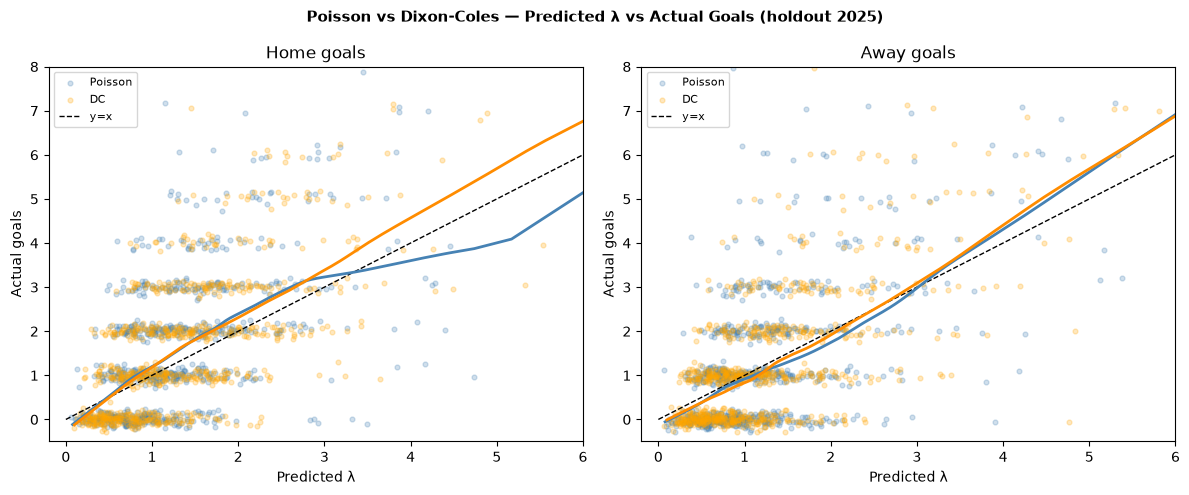


DC model globals restored.


In [12]:
RUN_COMPARISON = True  # set False before %run-ing this notebook from predictions.ipynb in production

if RUN_COMPARISON:
    # ---- Save DC model state before Poisson overwrites globals ----
    _dc = {
        'alpha':          dict(alpha_dict),
        'beta':           dict(beta_dict),
        'gamma':          float(GAMMA),
        'rho':            float(RHO),
        'draw_inflation': float(DRAW_INFLATION),
        'alpha_fb':       float(alpha_fallback),
        'beta_fb':        float(beta_fallback),
        'tmc':            dict(team_match_counts),
        'start_year':     BEST_START_YEAR,
        'xi':             BEST_XI,
        'ref':            REFERENCE_TEAM,
    }

    # DC helpers using saved params (closures over _dc, not globals)
    def _dc_get_params(canonical):
        n = int(_dc['tmc'].get(canonical, 0))
        if canonical not in _dc['alpha']:
            return _dc['alpha_fb'], _dc['beta_fb']
        a, b = _dc['alpha'][canonical], _dc['beta'][canonical]
        if n < 5:
            w = n / (n + 5)
            return w*a + (1-w)*_dc['alpha_fb'], w*b + (1-w)*_dc['beta_fb']
        return a, b

    def _dc_predict_eg(home, away, neutral=True):
        ch, ca   = _canonical_team(home), _canonical_team(away)
        a_h, b_h = _dc_get_params(ch)
        a_a, b_a = _dc_get_params(ca)
        g_eff    = _dc['gamma'] if (not neutral and ch in _HOST_NATIONS) else 0.0
        return float(np.exp(a_h + b_a + g_eff)), float(np.exp(a_a + b_h))

    def _dc_predict_wp(home, away, neutral=True):
        lh, la = _dc_predict_eg(home, away, neutral)
        hpm = poisson_dist.pmf(np.arange(MAX_GOALS + 1), lh)
        apm = poisson_dist.pmf(np.arange(MAX_GOALS + 1), la)
        mat = np.outer(hpm, apm)
        rho = _dc['rho']
        mat[0,0] = max(1e-15, mat[0,0] * (1.0 - lh * la * rho))
        mat[0,1] = max(1e-15, mat[0,1] * (1.0 + lh * rho))
        mat[1,0] = max(1e-15, mat[1,0] * (1.0 + la * rho))
        mat[1,1] = max(1e-15, mat[1,1] * (1.0 - rho))
        mat /= mat.sum()
        return _matrix_outcomes(mat)

    # ---- Load Poisson model (overwrites globals including predict_expected_goals) ----
    print('Loading poisson_model.ipynb for comparison...')
    %run ../models/poisson_model.ipynb

    # Poisson predict functions are now in globals
    _poisson_predict_eg = predict_expected_goals
    _poisson_predict_wp = predict_win_probabilities

    # ---- Evaluate both models on the holdout set ----
    rows = []
    for _, r in df_holdout.iterrows():
        hg, ag = int(r['home_score']), int(r['away_score'])
        ht, at = r['home_team'], r['away_team']
        neut   = bool(r['neutral'])

        # Actual outcome
        if hg > ag:    actual = 'home_win'
        elif hg == ag: actual = 'draw'
        else:          actual = 'away_win'

        # Poisson predictions
        lh_p, la_p         = _poisson_predict_eg(ht, at, neut)
        pw_p, pd_p, pa_p   = _poisson_predict_wp(ht, at, neut)

        # DC predictions (using saved params)
        lh_d, la_d         = _dc_predict_eg(ht, at, neut)
        pw_d, pd_d, pa_d   = _dc_predict_wp(ht, at, neut)

        rows.append({
            'hg': hg, 'ag': ag, 'actual': actual,
            'lh_p': lh_p, 'la_p': la_p,
            'pw_p': pw_p, 'pd_p': pd_p, 'pa_p': pa_p,
            'lh_d': lh_d, 'la_d': la_d,
            'pw_d': pw_d, 'pd_d': pd_d, 'pa_d': pa_d,
        })

    ev = pd.DataFrame(rows)

    def _model_metrics(lh_col, la_col, pw_col, pd_col, pa_col, df):
        mae_h  = float((df[lh_col] - df['hg']).abs().mean())
        mae_a  = float((df[la_col] - df['ag']).abs().mean())
        rps_vals = [_rps(r[pw_col], r[pd_col], r[pa_col], r['hg'], r['ag'])
                    for _, r in df.iterrows()]
        rps    = float(np.mean(rps_vals))
        brier  = float(((df[pw_col] - (df['actual'] == 'home_win').astype(float)) ** 2).mean())
        ll_vals = []
        for _, r in df.iterrows():
            eps = 1e-15
            if r['actual'] == 'home_win': p = r[pw_col]
            elif r['actual'] == 'draw':   p = r[pd_col]
            else:                         p = r[pa_col]
            ll_vals.append(-np.log(max(eps, p)))
        logloss = float(np.mean(ll_vals))
        top_p   = df[[pw_col, pd_col, pa_col]].idxmax(axis=1)
        pred_outcome = top_p.map({pw_col: 'home_win', pd_col: 'draw', pa_col: 'away_win'})
        accuracy = float((pred_outcome == df['actual']).mean())
        return {'MAE (home λ)': mae_h, 'MAE (away λ)': mae_a,
                'RPS': rps, 'Brier Score': brier, 'Log-Loss': logloss, 'Accuracy': accuracy}

    poisson_m = _model_metrics('lh_p','la_p','pw_p','pd_p','pa_p', ev)
    dc_m      = _model_metrics('lh_d','la_d','pw_d','pd_d','pa_d', ev)

    comp_df = pd.DataFrame({'Poisson': poisson_m, 'DC': dc_m})
    print(f'\n=== Model Comparison (holdout: {holdout_year}, n={len(ev)} matches) ===')
    print(comp_df.to_string(float_format='{:.4f}'.format))

    # ---- Scatter plots ----
    try:
        from statsmodels.nonparametric.smoothers_lowess import lowess as sm_lowess
        def _lowess_smooth(x, y):
            idx = np.argsort(x)
            xs, ys = x[idx], y[idx]
            sm = sm_lowess(ys, xs, frac=0.5, return_sorted=True)
            return sm[:, 0], sm[:, 1]
    except ImportError:
        def _lowess_smooth(x, y):
            idx = np.argsort(x)
            xs, ys = x[idx], y[idx]
            z = np.polyfit(xs, ys, 3)
            return xs, np.poly1d(z)(xs)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    ref_line = np.linspace(0, 6, 50)

    for ax, (lh_col, la_col, title, goals_col) in zip(axes, [
        ('lh_p', 'lh_d', 'Home goals', 'hg'),
        ('la_p', 'la_d', 'Away goals', 'ag'),
    ]):
        actual = ev[goals_col].values.astype(float)
        lam_p  = ev[lh_col if goals_col == 'hg' else la_col.replace('lh','la') if goals_col == 'ag'
                   else lh_col].values
        lam_p  = ev['lh_p' if goals_col == 'hg' else 'la_p'].values
        lam_d  = ev['lh_d' if goals_col == 'hg' else 'la_d'].values

        ax.scatter(lam_p + np.random.randn(len(lam_p)) * 0.02,
                   actual + np.random.randn(len(actual)) * 0.1,
                   alpha=0.25, s=12, color='steelblue', label='Poisson')
        ax.scatter(lam_d + np.random.randn(len(lam_d)) * 0.02,
                   actual + np.random.randn(len(actual)) * 0.1,
                   alpha=0.25, s=12, color='orange', label='DC')
        ax.plot(ref_line, ref_line, 'k--', lw=1, label='y=x')

        try:
            xs_p, ys_p = _lowess_smooth(lam_p, actual)
            xs_d, ys_d = _lowess_smooth(lam_d, actual)
            ax.plot(xs_p, ys_p, '-', color='steelblue', lw=2)
            ax.plot(xs_d, ys_d, '-', color='darkorange', lw=2)
        except Exception:
            pass

        ax.set_xlabel('Predicted λ')
        ax.set_ylabel('Actual goals')
        ax.set_title(title)
        ax.legend(fontsize=8)
        ax.set_xlim(-0.2, 6)
        ax.set_ylim(-0.5, 8)

    fig.suptitle(f'Poisson vs Dixon-Coles — Predicted λ vs Actual Goals (holdout {holdout_year})',
                 fontsize=11, fontweight='bold')
    plt.tight_layout()
    out_path = OUTPUTS / 'dc_vs_poisson_comparison.png'
    plt.savefig(out_path, dpi=150, bbox_inches='tight')
    print(f'\nComparison chart saved to {out_path}')
    plt.show()

    # ---- Restore DC globals so the notebook remains usable after this section ----
    alpha_dict        = _dc['alpha']
    beta_dict         = _dc['beta']
    GAMMA             = _dc['gamma']
    RHO               = _dc['rho']
    DRAW_INFLATION    = _dc['draw_inflation']
    alpha_fallback    = _dc['alpha_fb']
    beta_fallback     = _dc['beta_fb']
    team_match_counts = _dc['tmc']
    REFERENCE_TEAM    = _dc['ref']
    BEST_START_YEAR   = _dc['start_year']
    BEST_XI           = _dc['xi']
    print('\nDC model globals restored.')
else:
    print('RUN_COMPARISON = False — skipping model comparison section.')

---
## Section 10 — Integration Tests

**Verification:** check the Section 6 fallback log first. `"USA"` / `"United States"`
must NOT appear there. The fourth match (`USA vs Mexico, neutral=False`) exercises
the canonicalization and home-advantage code path.

In [13]:
test_matches = [
    ('France',   'Argentina', True),
    ('Spain',    'Brazil',    True),
    ('Germany',  'England',   True),
    ('USA',      'Mexico',    False),  # host nation home — exercises canonicalization + γ path
]

print('=' * 80)
print('INTEGRATION TESTS — Dixon-Coles Model')
print('=' * 80)

# Expected goals & win probabilities
print('\n--- Expected Goals & Win Probabilities ---')
hdr = f'{"Match":<30} {"neut":>5}  {"λ_home":>7} {"λ_away":>7}  {"P(hw)":>7} {"P(draw)":>7} {"P(aw)":>7}'
print(hdr)
print('-' * len(hdr))
for home, away, neutral in test_matches:
    lh, la      = predict_expected_goals(home, away, neutral)
    pw, pd_, pa = predict_win_probabilities(home, away, neutral)
    label       = f'{home} vs {away}'
    print(f'{label:<30} {str(neutral):>5}  {lh:>7.3f} {la:>7.3f}  {pw:>7.3f} {pd_:>7.3f} {pa:>7.3f}')

# Group match
print('\n--- Group match (draw inflation applied) ---')
print(f'{"Match":<30} {"neut":>5}  {"HG":>3} {"AG":>3}  Result')
print('-' * 55)
for home, away, neutral in test_matches:
    hg, ag, winner = predict_group_match(home, away, neutral)
    label  = f'{home} vs {away}'
    result = winner if winner is not None else 'Draw'
    print(f'{label:<30} {str(neutral):>5}  {hg:>3} {ag:>3}  {result}')

# Knockout
print('\n--- Knockout (no draws, renormalized) ---')
print(f'{"Match":<30} {"neut":>5}  {"Winner":<22} {"Win prob":>9}')
print('-' * 70)
for home, away, neutral in test_matches:
    w, l, wp, lp = predict_knockout_winner(home, away, neutral)
    label = f'{home} vs {away}'
    print(f'{label:<30} {str(neutral):>5}  {w:<22} {wp:>9.4f}')

INTEGRATION TESTS — Dixon-Coles Model

--- Expected Goals & Win Probabilities ---
Match                           neut   λ_home  λ_away    P(hw) P(draw)   P(aw)
------------------------------------------------------------------------------
France vs Argentina             True    0.831   0.959    0.301   0.329   0.370
Spain vs Brazil                 True    1.717   0.779    0.598   0.235   0.167
Germany vs England              True    0.877   1.271    0.257   0.288   0.455
USA vs Mexico                  False    1.039   1.261    0.305   0.282   0.414

--- Group match (draw inflation applied) ---
Match                           neut   HG  AG  Result
-------------------------------------------------------
France vs Argentina             True    0   0  Draw
Spain vs Brazil                 True    1   0  Spain
Germany vs England              True    0   1  England
USA vs Mexico                  False    1   1  Draw

--- Knockout (no draws, renormalized) ---
Match                           n

In [14]:
print('=' * 60)
print('MODEL READY — Dixon-Coles (Episode 4)')
print('=' * 60)
print(f'  Selected start year  : {BEST_START_YEAR}')
print(f'  Selected ξ           : {BEST_XI}')
print(f'  Reference team       : "{REFERENCE_TEAM}"')
print(f'  γ (home advantage)   : {GAMMA:.4f}')
print(f'  ρ (Dixon-Coles τ)    : {RHO:.4f}')
print(f'  Draw inflation       : {DRAW_INFLATION:.4f}')
print(f'  α fallback           : {alpha_fallback:.4f}')
print(f'  β fallback           : {beta_fallback:.4f}')
print()
print('To use in predictions.ipynb (set RUN_COMPARISON=False first):')
print('  %run dc_model.ipynb')

MODEL READY — Dixon-Coles (Episode 4)
  Selected start year  : 2000
  Selected ξ           : 0.5
  Reference team       : "Iraqi Kurdistan"
  γ (home advantage)   : 0.2659
  ρ (Dixon-Coles τ)    : -0.0194
  Draw inflation       : 1.0000
  α fallback           : 0.0244
  β fallback           : 0.0738

To use in predictions.ipynb (set RUN_COMPARISON=False first):
  %run dc_model.ipynb
